### Exploratory data analysis 

This notebook explores the cleaned Kepler KOI binary classification dataset.

Main questions:

1. Is the target balanced or imbalanced?
2. Which features have missing values?
3. Which features are strongly skewed?
4. Which features visibly separate planet-like objects from false positives?
5. Which transformations should we consider in the modeling pipeline?

This notebook does not train the final ML model. That belongs in `03_modeling.ipynb`.

In [4]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# define project data directory
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
REPORTS_DIR = DATA_DIR / 'reports'

data_file = PROCESSED_DIR / "kepler_koi_binary.csv"
metadata_file = REPORTS_DIR / "data_metadata.json"

df = pd.read_csv(data_file)

with open(metadata_file, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4725, 24)


,kepid,kepoi_name,kepler_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,...,koi_steff,koi_slogg,koi_smet,koi_srad,koi_smass,ra,dec,koi_kepmag,planet,planet_label
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,9.488036,0.146,2.9575,615.8,2.26,793.0,...,5455.0,4.467,0.14,0.927,0.919,291.93423,48.141651,15.347,1,confirmed
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,54.418383,0.586,4.5070,874.8,2.83,443.0,...,5455.0,4.467,0.14,0.927,0.919,291.93423,48.141651,15.347,1,confirmed
2,10811496,K00753.01,NaN,CANDIDATE,19.899140,0.969,1.7822,10829.0,14.60,638.0,...,5853.0,4.544,-0.18,0.868,0.961,297.00482,48.134129,15.436,0,candidate
3,10854555,K00755.01,Kepler-664 b,CONFIRMED,2.525592,0.701,1.6545,603.3,2.75,1406.0,...,6031.0,4.438,0.07,1.046,1.095,288.75488,48.226200,15.509,1,confirmed
4,10872983,K00756.01,Kepler-228 d,CONFIRMED,11.094321,0.538,4.5945,1517.5,3.90,835.0,...,6046.0,4.486,-0.08,0.972,1.053,296.28613,48.224670,15.714,1,confirmed


In [6]:
ID_COLUMNS = metadata["id_columns"]
TARGET_COLUMNS = metadata["target_columns"]
NUMERIC_COLUMNS = metadata["numeric_columns"]

TARGET = "planet"

print("ID columns:", ID_COLUMNS)
print("Target:", TARGET)
print("Number of numeric columns:", len(NUMERIC_COLUMNS))


ID columns: ['kepid', 'kepoi_name', 'kepler_name']
Target: planet
Number of numeric columns: 18


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4725 entries, 0 to 4724
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kepid             4725 non-null   int64  
 1   kepoi_name        4725 non-null   object 
 2   kepler_name       2745 non-null   object 
 3   koi_disposition   4725 non-null   object 
 4   koi_period        4725 non-null   float64
 5   koi_impact        4619 non-null   float64
 6   koi_duration      4725 non-null   float64
 7   koi_depth         4619 non-null   float64
 8   koi_prad          4619 non-null   float64
 9   koi_teq           4619 non-null   float64
 10  koi_insol         4622 non-null   float64
 11  koi_model_snr     4619 non-null   float64
 12  koi_count         4725 non-null   int64  
 13  koi_num_transits  4252 non-null   float64
 14  koi_steff         4619 non-null   float64
 15  koi_slogg         4619 non-null   float64
 16  koi_smet          4616 non-null   float64


In [8]:
target_counts = df["planet_label"].value_counts()
target_percentages = df["planet_label"].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages,
})

target_summary

,count,percentage
planet_label,,
confirmed,2747,58.14
candidate,1978,41.86


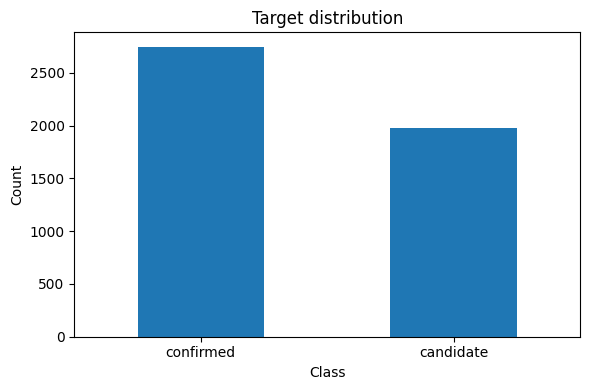

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

target_counts.plot(kind="bar", ax=ax)

ax.set_title("Target distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [13]:
missing_summary = (
    df
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("missing_percentage")
)

missing_summary["missing_count"] = df.isna().sum()
missing_summary

,missing_percentage,missing_count
kepler_name,41.904762,1980
koi_num_transits,10.010582,473
koi_smet,2.306878,109
koi_impact,2.243386,106
koi_prad,2.243386,106
koi_model_snr,2.243386,106
koi_depth,2.243386,106
koi_slogg,2.243386,106
koi_smass,2.243386,106
koi_steff,2.243386,106


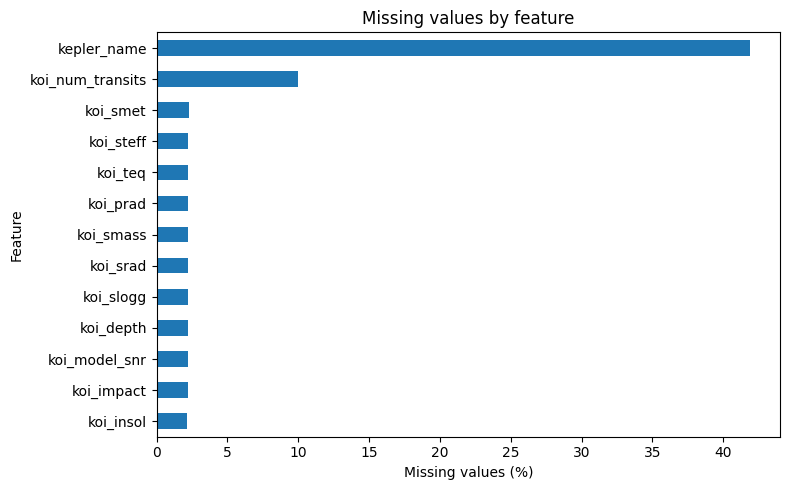

In [14]:
missing_nonzero = missing_summary[missing_summary["missing_percentage"] > 0]

fig, ax = plt.subplots(figsize=(8, 5))

missing_nonzero["missing_percentage"].sort_values().plot(kind="barh", ax=ax)

ax.set_title("Missing values by feature")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [20]:
missing_by_target = (
    df
    .groupby("planet_label")[NUMERIC_COLUMNS]
    .apply(lambda x: x.isna().mean().mul(100))
    .T
)

missing_by_target["difference_abs"] = (
    missing_by_target.max(axis=1) - missing_by_target.min(axis=1)
)

missing_by_target.sort_values("difference_abs", ascending=False)

planet_label,candidate,confirmed,difference_abs
koi_num_transits,23.306370,0.436840,22.869530
koi_smet,5.409505,0.072807,5.336698
koi_smass,5.257836,0.072807,5.185029
koi_impact,5.257836,0.072807,5.185029
koi_teq,5.257836,0.072807,5.185029
koi_depth,5.257836,0.072807,5.185029
koi_model_snr,5.257836,0.072807,5.185029
koi_slogg,5.257836,0.072807,5.185029
koi_steff,5.257836,0.072807,5.185029
koi_prad,5.257836,0.072807,5.185029


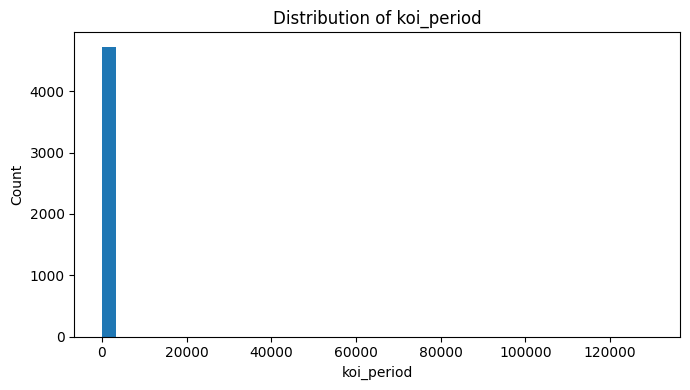

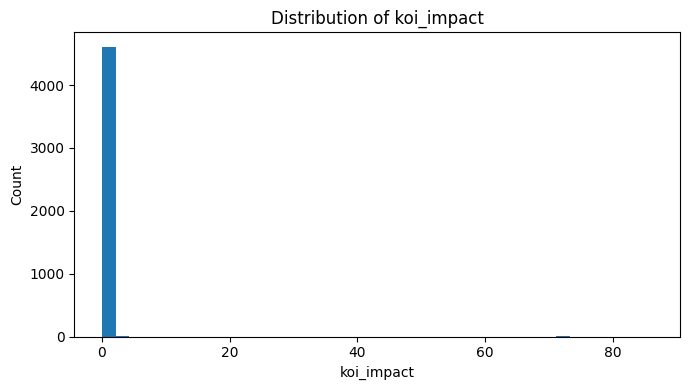

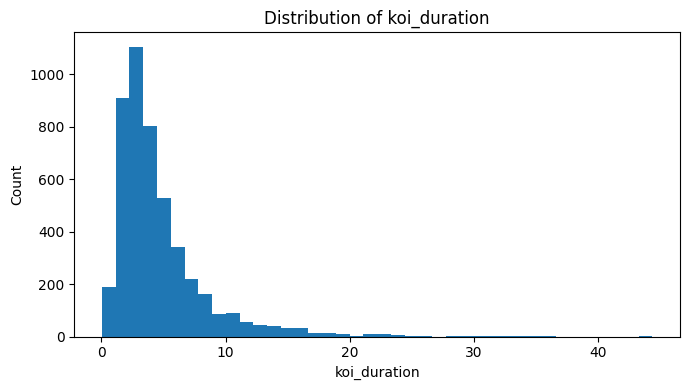

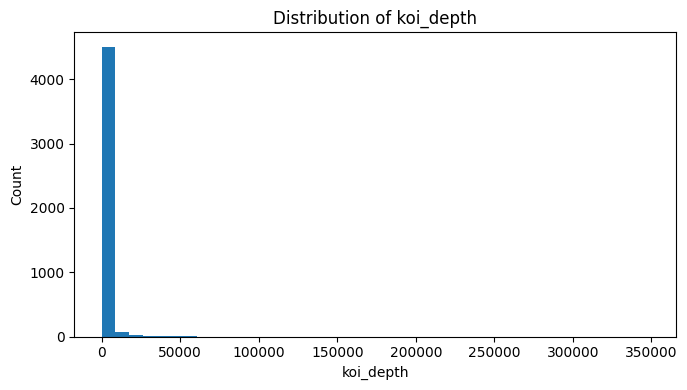

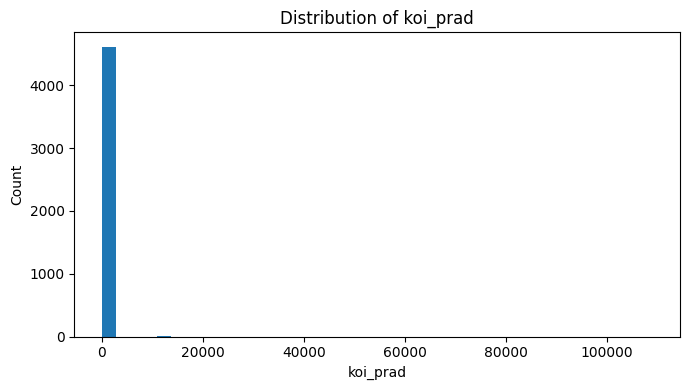

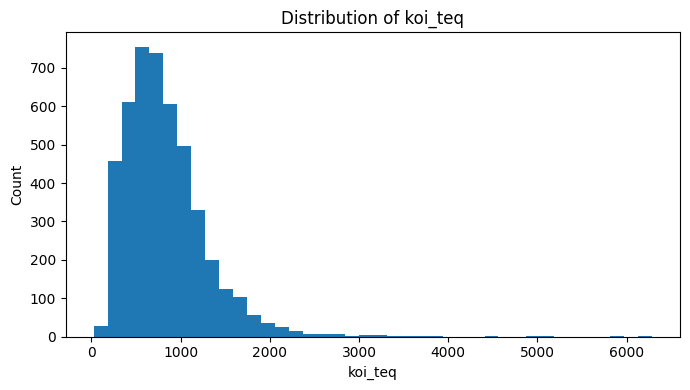

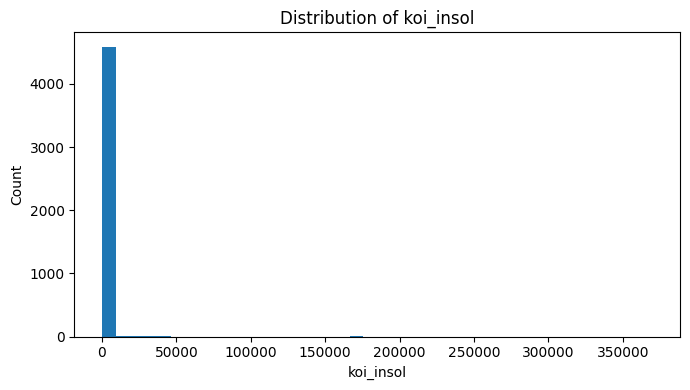

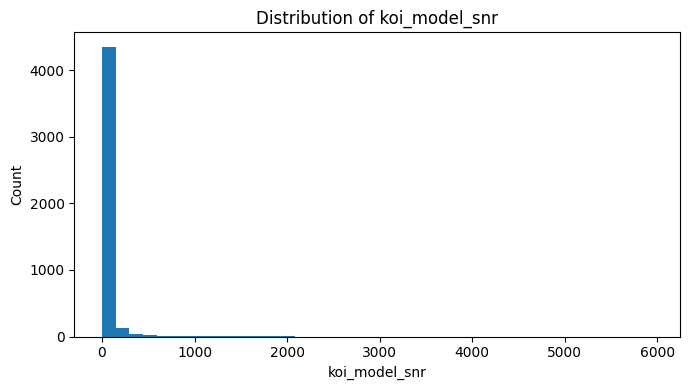

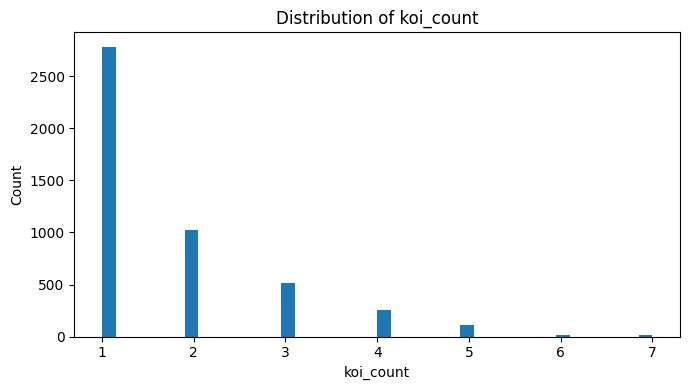

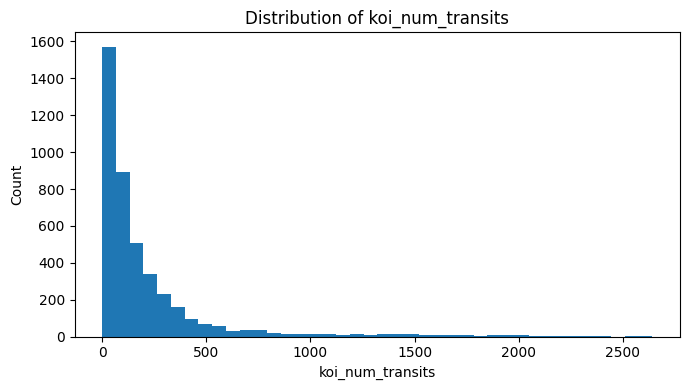

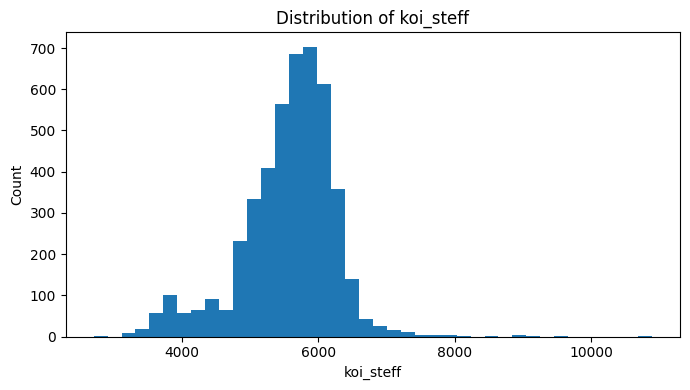

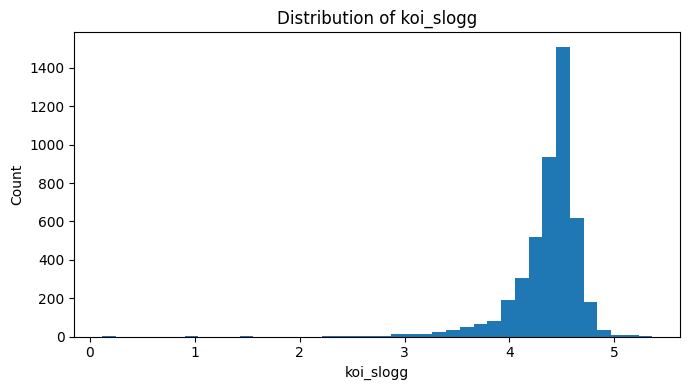

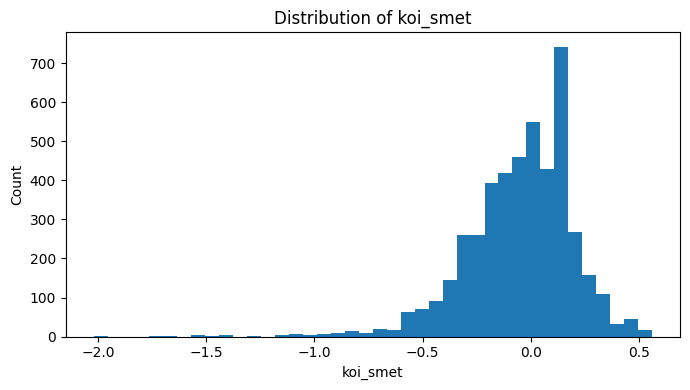

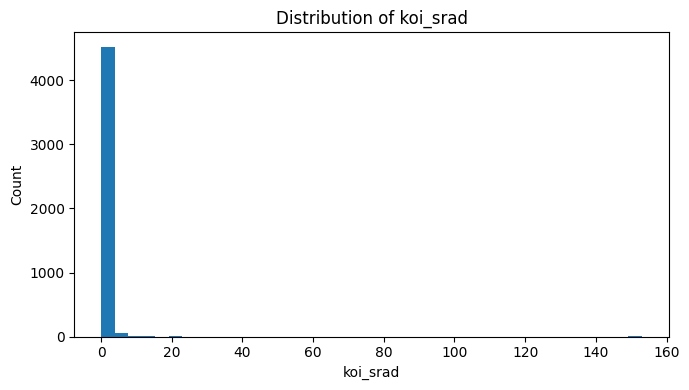

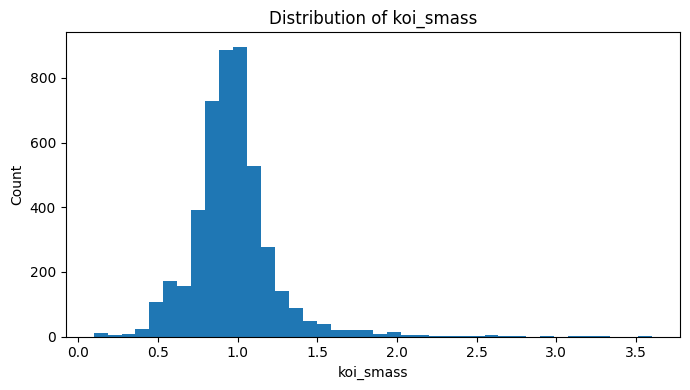

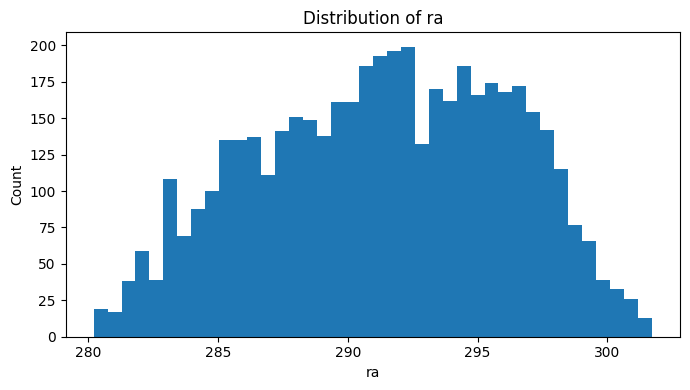

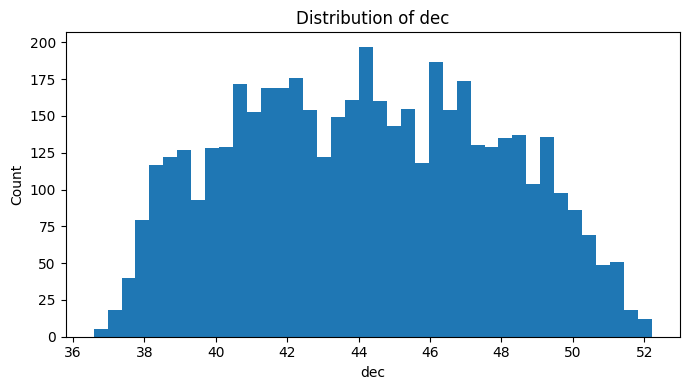

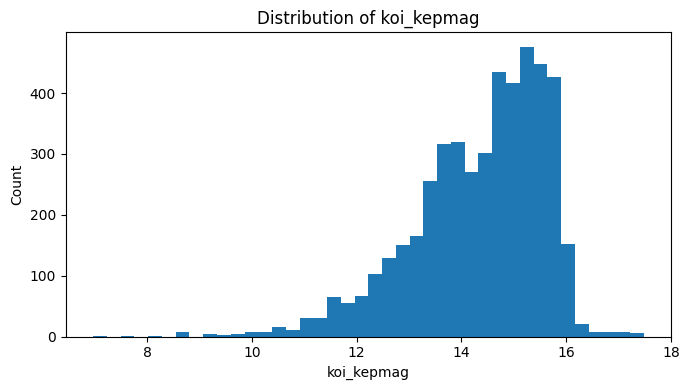

In [22]:
def plot_feature_histogram(data: pd.DataFrame, column: str, bins: int = 40) -> None:
    """
    Plot a simple histogram for one feature.
    """
    values = data[column].dropna()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(values, bins=bins)

    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()


for col in NUMERIC_COLUMNS:
    plot_feature_histogram(df, col)

In [25]:
candidate_log_columns = [
    "koi_period",
    "koi_duration",
    "koi_depth",
    "koi_prad",
    "koi_teq",
    "koi_insol",
    "koi_model_snr",
    "koi_num_transits",
    "koi_srad",
    "koi_smass",
]

log_transform_candidates = []

for col in candidate_log_columns:
    min_value = df[col].min(skipna=True)

    if pd.notna(min_value) and min_value >= 0:
        log_transform_candidates.append(col)

log_transform_candidates

['koi_period',
 'koi_duration',
 'koi_depth',
 'koi_prad',
 'koi_teq',
 'koi_insol',
 'koi_model_snr',
 'koi_num_transits',
 'koi_srad',
 'koi_smass']

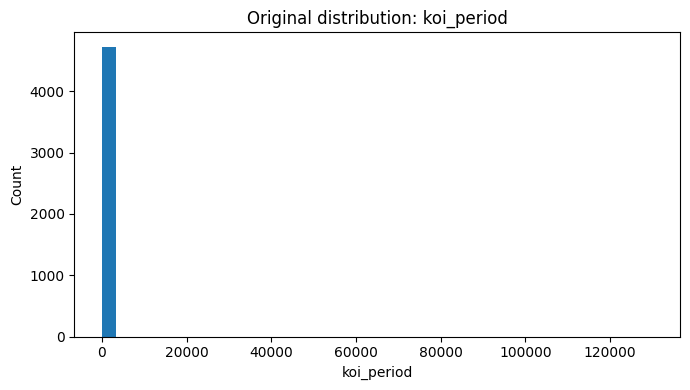

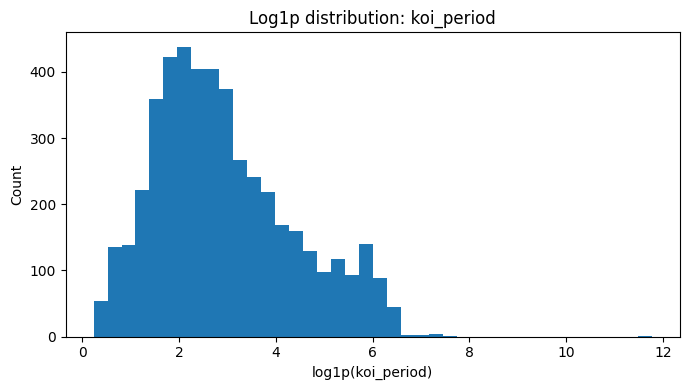

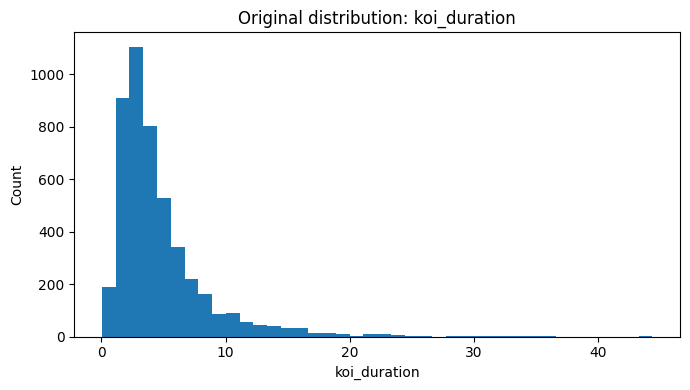

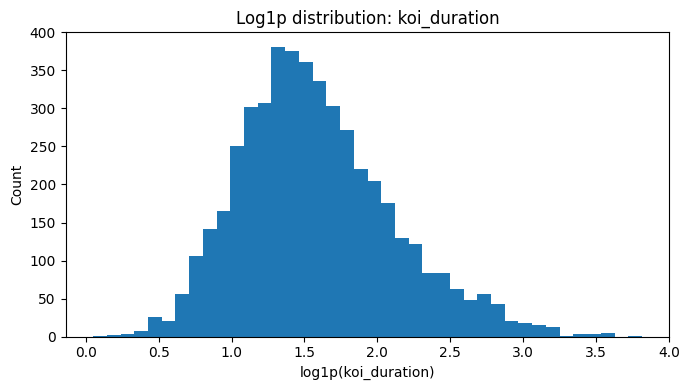

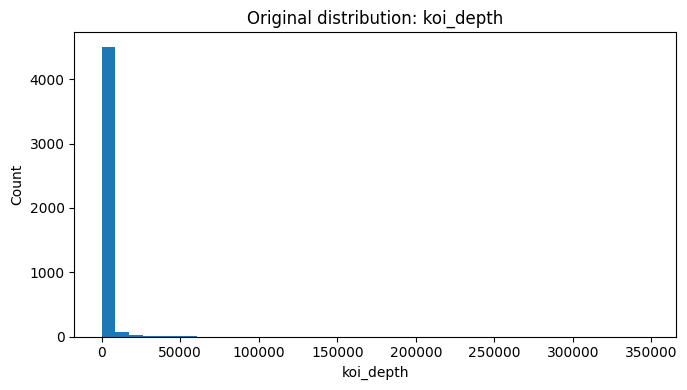

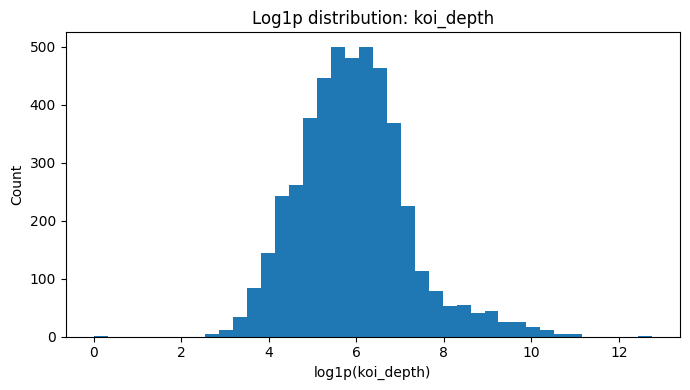

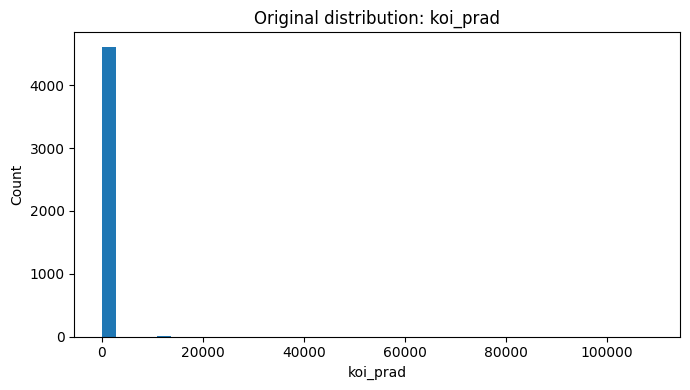

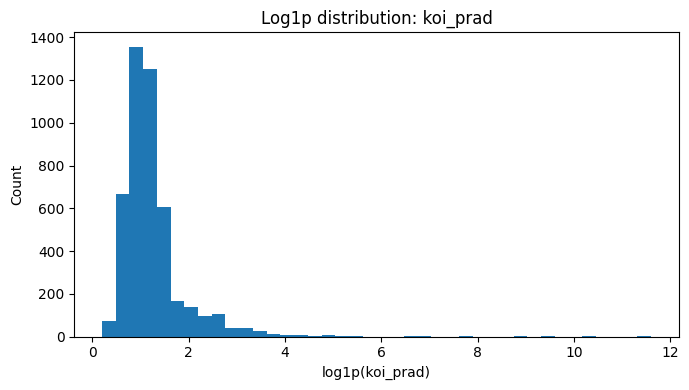

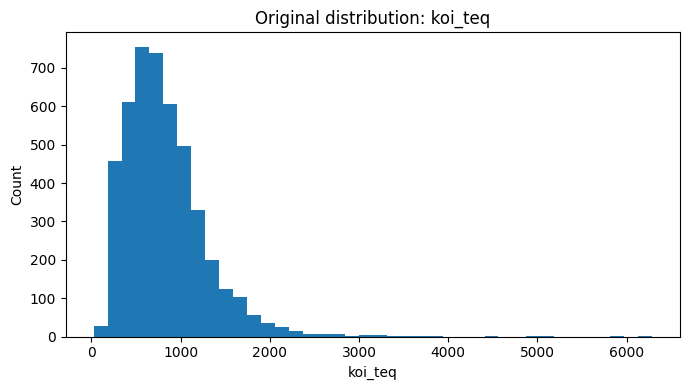

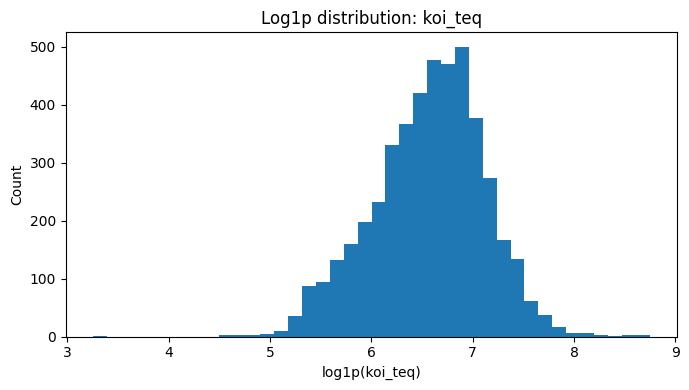

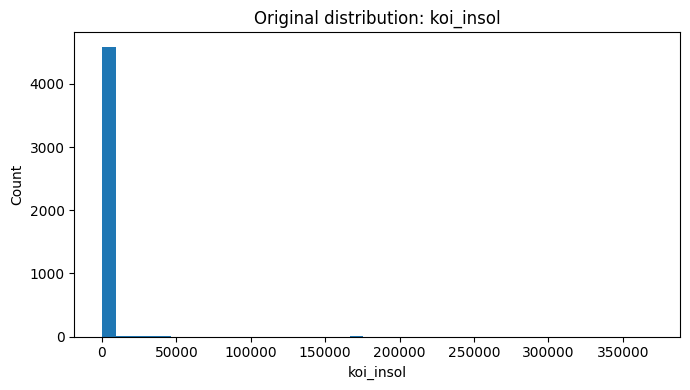

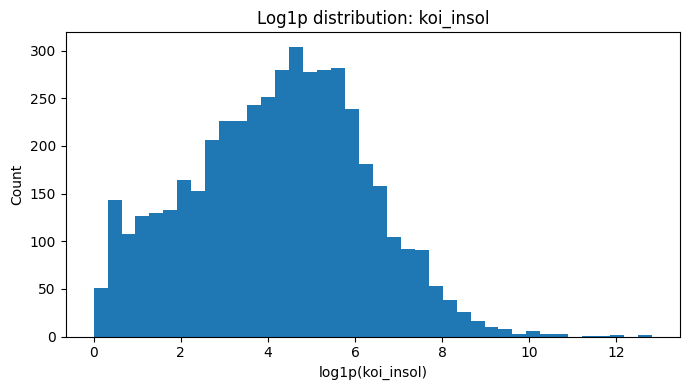

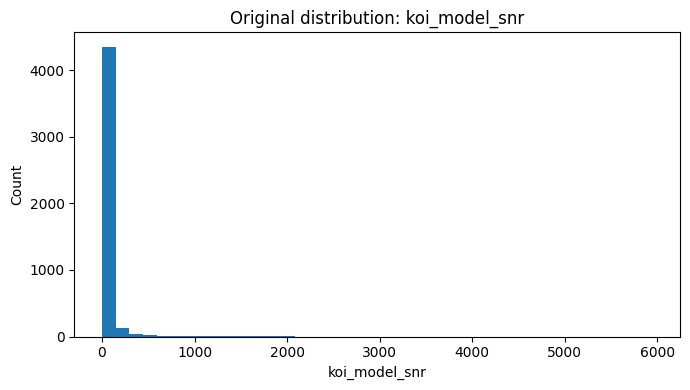

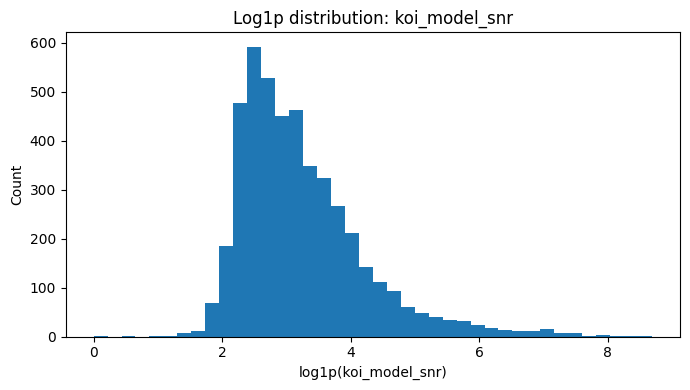

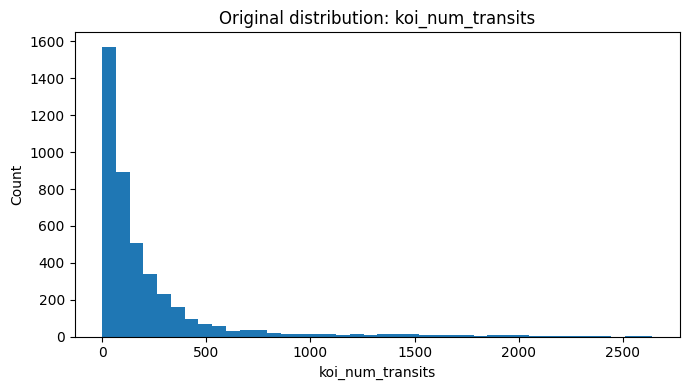

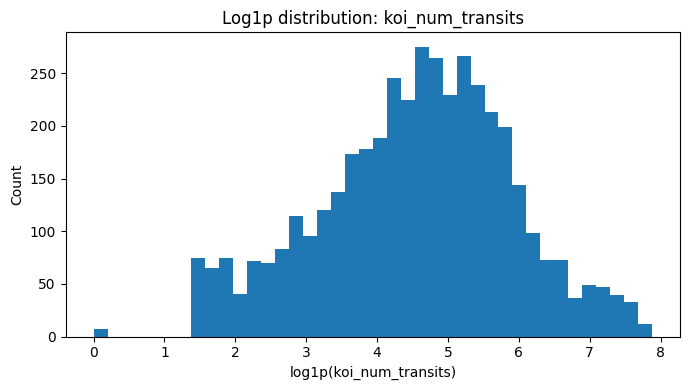

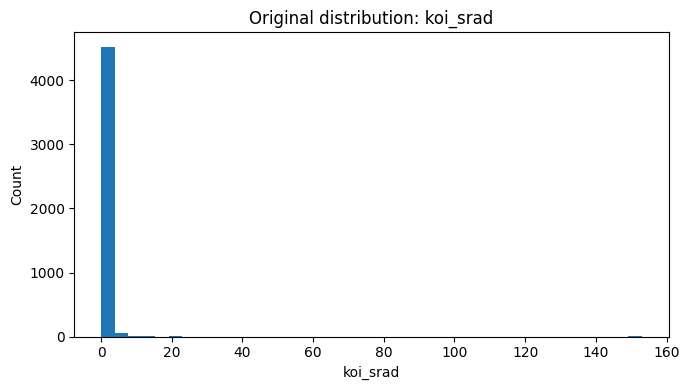

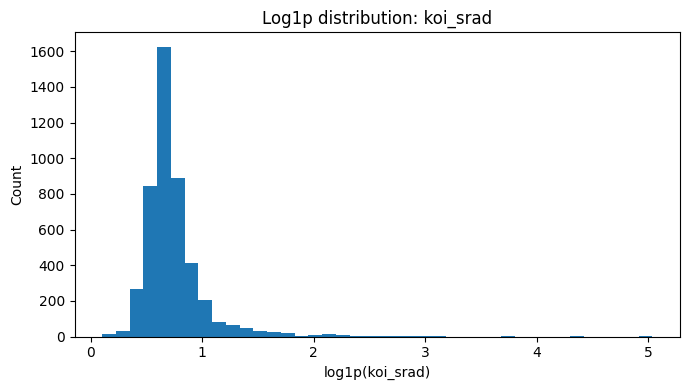

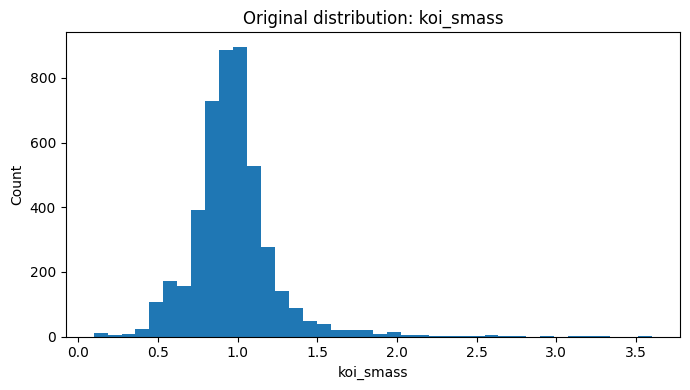

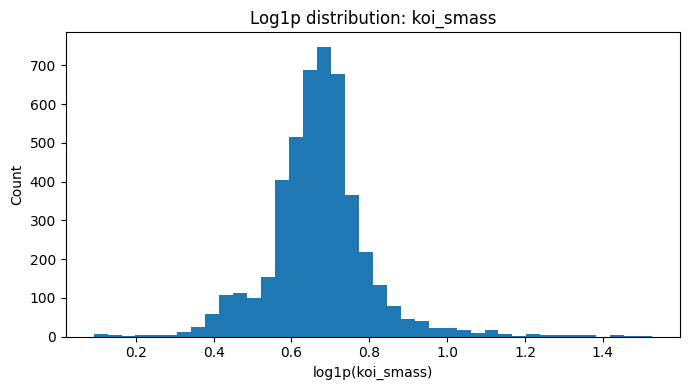

In [26]:
def plot_original_vs_log1p(data: pd.DataFrame, column: str, bins: int = 40) -> None:
    """
    Compare original and log1p-transformed distributions.
    """
    values = data[column].dropna()
    log_values = np.log1p(values)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(values, bins=bins)
    ax.set_title(f"Original distribution: {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(log_values, bins=bins)
    ax.set_title(f"Log1p distribution: {column}")
    ax.set_xlabel(f"log1p({column})")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()


for col in log_transform_candidates:
    plot_original_vs_log1p(df, col)

In [28]:
summary_by_target = (
    df
    .groupby("planet_label")[NUMERIC_COLUMNS]
    .agg(["mean", "median", "std", "min", "max"])
)

summary_by_target

koi_period                                                   \
                    mean     median          std       min            max   
planet_label                                                                
candidate     167.775170  20.043760  2925.553040  0.259820  129995.778400   
confirmed      27.904728  11.350106    56.529271  0.341842    1071.232624   

             koi_impact                                  ...        dec  \
                   mean  median       std  min      max  ...       mean   
planet_label                                             ...              
candidate      0.653296  0.3587  3.888490  0.0  86.1724  ...  44.095202   
confirmed      0.440816  0.4120  0.337922  0.0   1.3000  ...  44.288867   

                                                       koi_kepmag           \
                median       std        min        max       mean   median   
planet_label                                                                 
candidate     44.08622  3.693951  36.771042  52.220341  14.317003  14.6035   
confirmed     44.25053  3.581969  36.577381  52.149132  14.356544  14.6150   

                                       
                   std    min     max  
planet_label                           
candidate     1.318259  6.974  17.376  
confirmed     1.230673  8.224  17.475  

[2 rows x 90 columns]

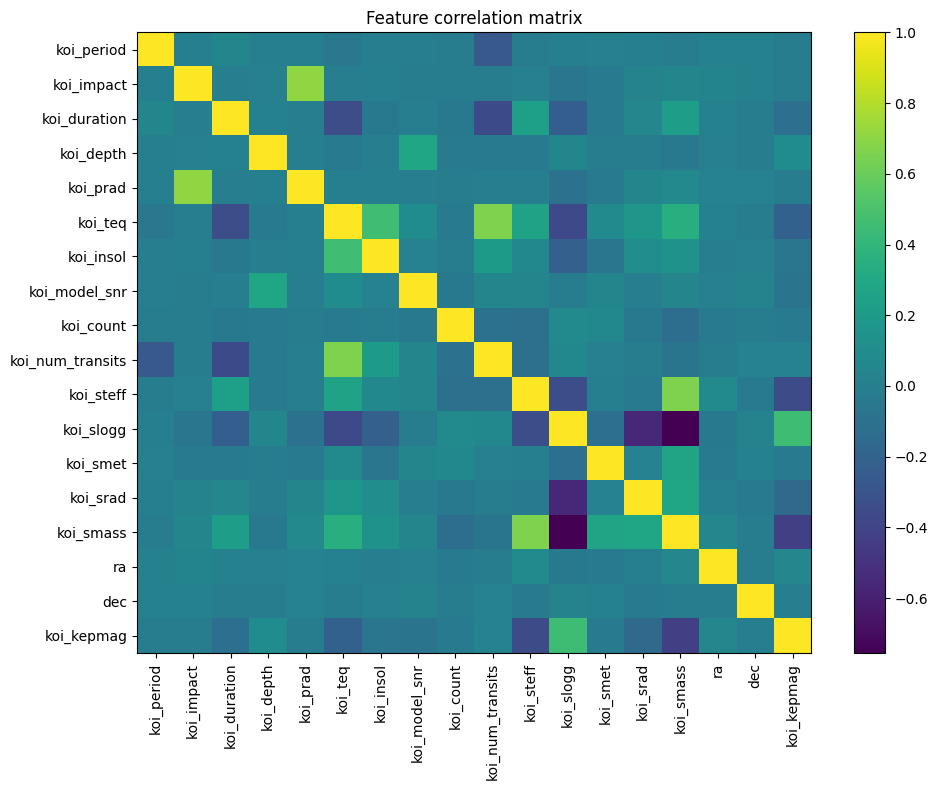

In [30]:
corr = df[NUMERIC_COLUMNS].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, aspect="auto")
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

ax.set_title("Feature correlation matrix")

plt.tight_layout()
plt.show()

In [31]:
# Show strongest absolute correlations between feature pairs.
corr_pairs = (
    corr
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

corr_pairs.sort_values("abs_correlation", ascending=False).head(20)

,feature_1,feature_2,correlation,abs_correlation
134,koi_slogg,koi_smass,-0.755134,0.755134
19,koi_impact,koi_prad,0.705197,0.705197
78,koi_teq,koi_num_transits,0.661663,0.661663
128,koi_steff,koi_smass,0.657433,0.657433
133,koi_slogg,koi_srad,-0.556926,0.556926
75,koi_teq,koi_insol,0.461765,0.461765
137,koi_slogg,koi_kepmag,0.452017,0.452017
149,koi_smass,koi_kepmag,-0.421165,0.421165
80,koi_teq,koi_slogg,-0.367693,0.367693
39,koi_duration,koi_num_transits,-0.358856,0.358856


In [32]:
target_corr = (
    df[NUMERIC_COLUMNS + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame("correlation_with_target")
)

target_corr

,correlation_with_target
koi_count,0.289118
koi_smet,0.203505
koi_slogg,0.160448
koi_smass,-0.157504
koi_steff,-0.134663
koi_duration,-0.132742
koi_model_snr,0.112273
koi_srad,-0.079478
ra,-0.072963
koi_insol,-0.056718


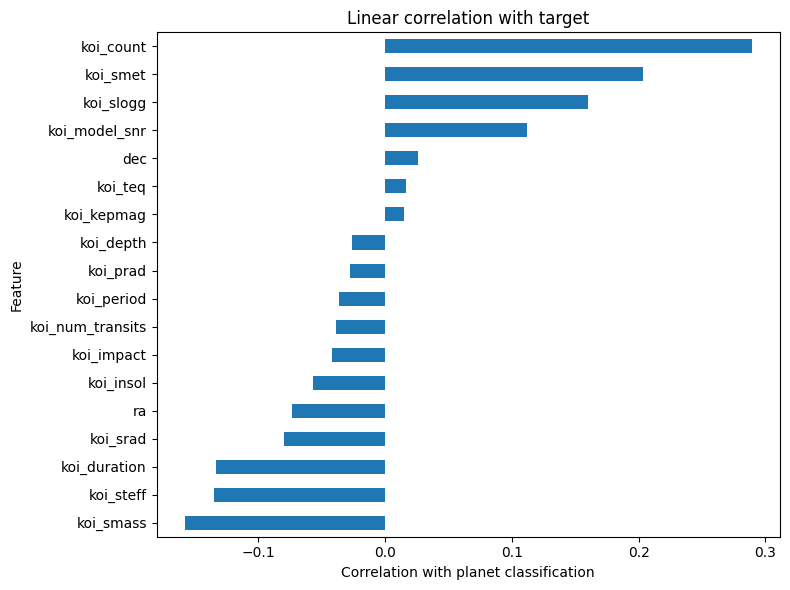

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))

target_corr.sort_values("correlation_with_target")["correlation_with_target"].plot(
    kind="barh",
    ax=ax,
)

ax.set_title("Linear correlation with target")
ax.set_xlabel("Correlation with planet classification")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [35]:
def outlier_summary_iqr(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """
    Calculate simple IQR-based outlier counts for numeric columns.
    """
    rows = []

    for col in columns:
        series = data[col].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_count = ((series < lower) | (series > upper)).sum()
        outlier_percentage = outlier_count / len(series) * 100 if len(series) > 0 else np.nan

        rows.append({
            "feature": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": outlier_count,
            "outlier_percentage": outlier_percentage,
        })

    return pd.DataFrame(rows)


outliers = outlier_summary_iqr(df, NUMERIC_COLUMNS)
outliers.sort_values("outlier_percentage", ascending=False)

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,koi_period,5.508607,43.397562,37.888955,-51.324826,100.230995,695,14.708995
6,koi_insol,15.415000,272.595000,257.180000,-370.355000,658.365000,577,12.483773
4,koi_prad,1.360000,2.950000,1.590000,-1.025000,5.335000,522,11.301147
7,koi_model_snr,11.700000,39.300000,27.600000,-29.700000,80.700000,501,10.846504
3,koi_depth,163.350000,766.950000,603.600000,-742.050000,1672.350000,435,9.417623
9,koi_num_transits,38.000000,238.000000,200.000000,-262.000000,538.000000,370,8.701787
8,koi_count,1.000000,2.000000,1.000000,-0.500000,3.500000,400,8.465608
13,koi_srad,0.816000,1.237500,0.421500,0.183750,1.869750,364,7.880494
2,koi_duration,2.348000,5.623000,3.275000,-2.564500,10.535500,329,6.962963
11,koi_slogg,4.274000,4.551000,0.277000,3.858500,4.966500,288,6.235116


Skipping log transform for koi_smet because it has negative values.


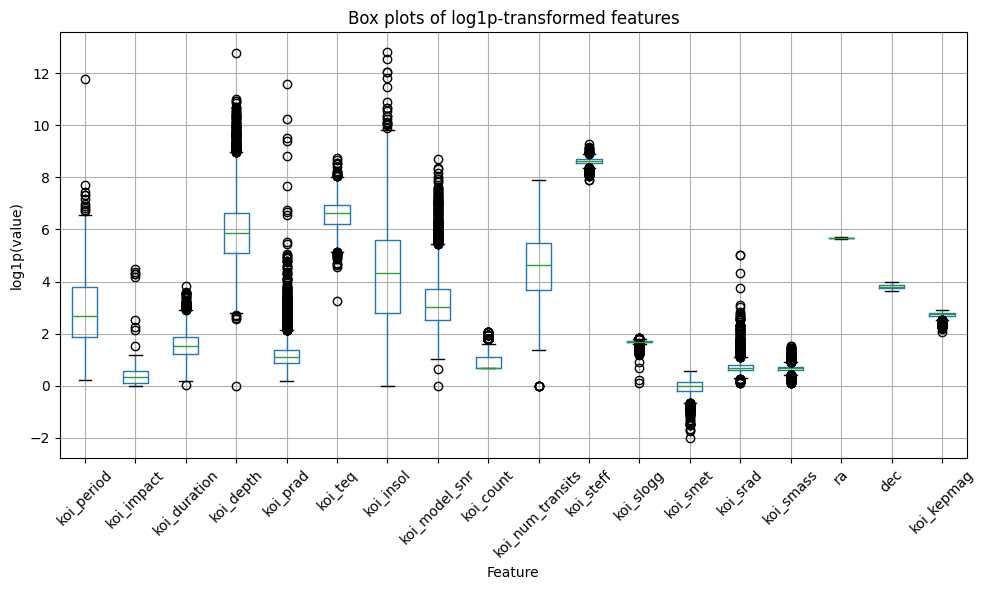

In [52]:
df_log = df[NUMERIC_COLUMNS].copy()

for col in NUMERIC_COLUMNS:
    if df_log[col].min(skipna=True) >= 0:
        df_log[col] = np.log1p(df_log[col])
    else:
        print(f"Skipping log transform for {col} because it has negative values.")

fig, ax = plt.subplots(figsize=(10, 6))

df_log.boxplot(ax=ax)

ax.set_title("Box plots of log1p-transformed features")
ax.set_xlabel("Feature")
ax.set_ylabel("log1p(value)")
ax.tick_params(axis="x", rotation=45)
# ax.set_yscale('log')

plt.tight_layout()
plt.show()

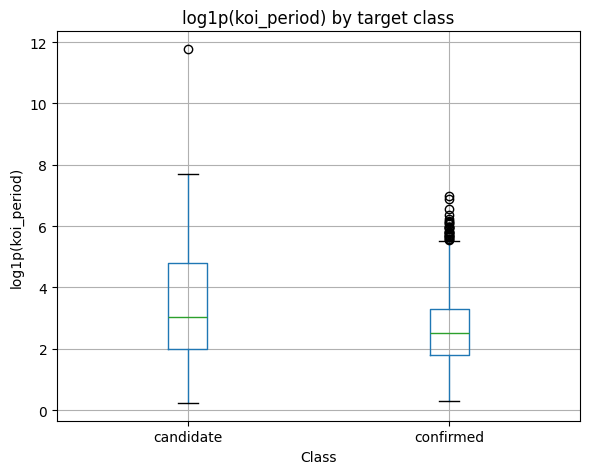

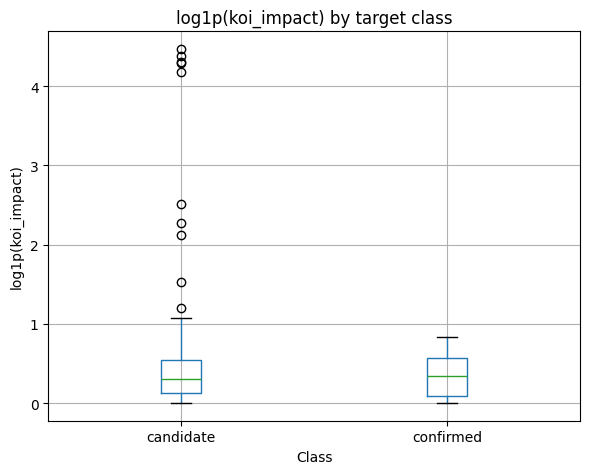

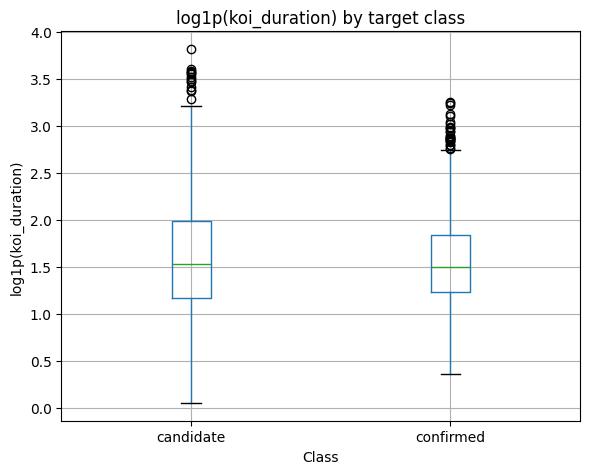

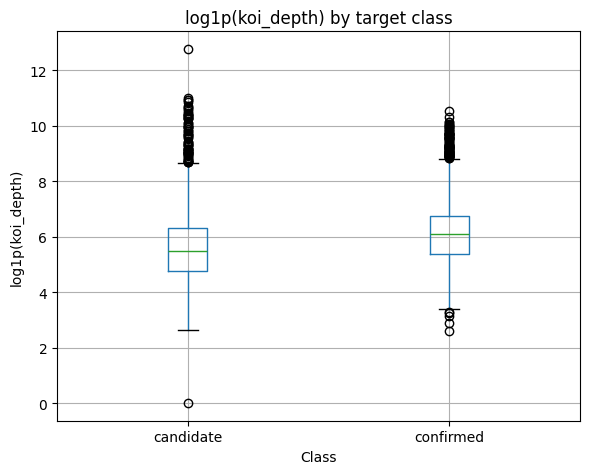

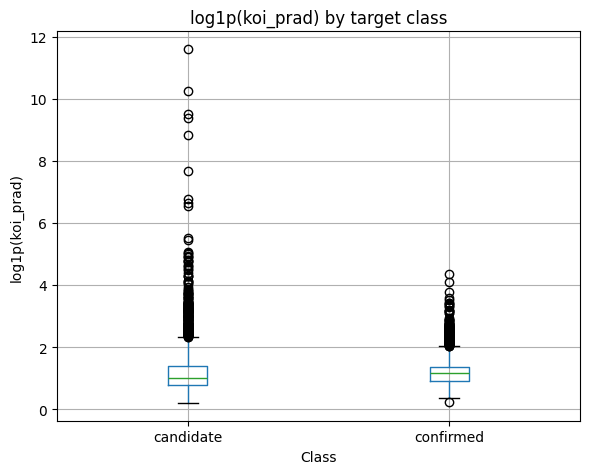

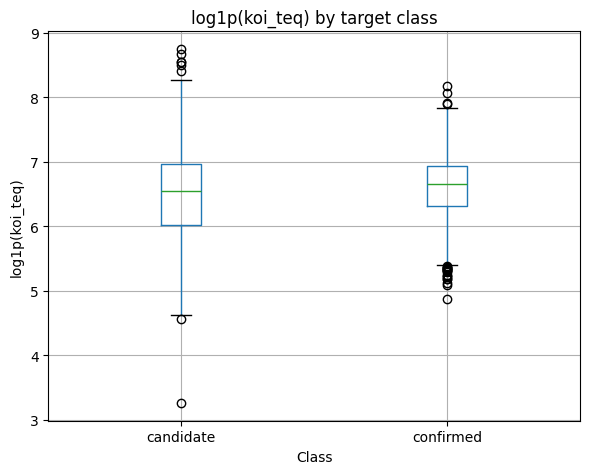

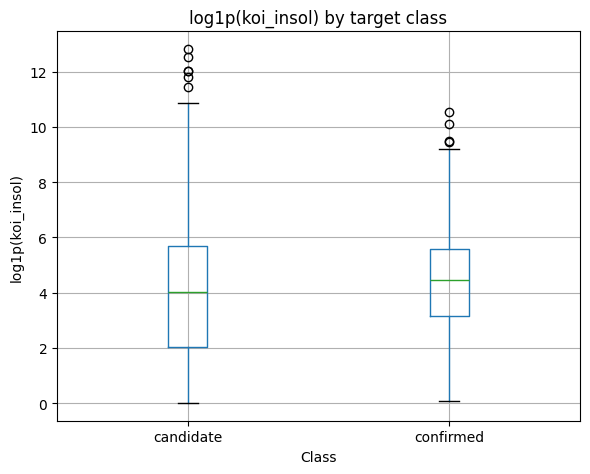

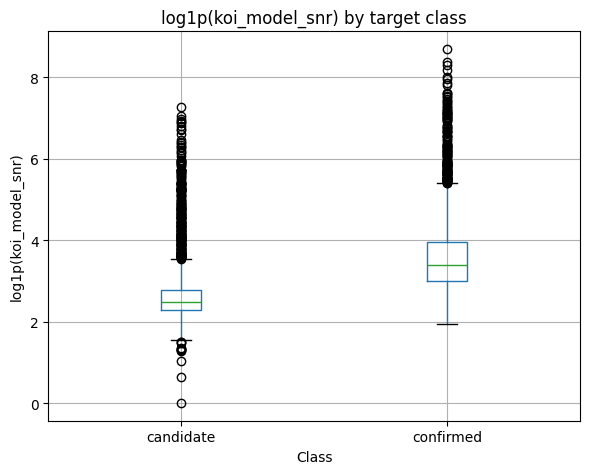

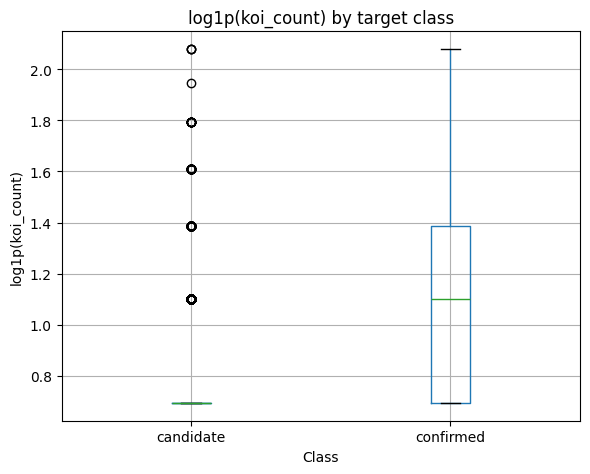

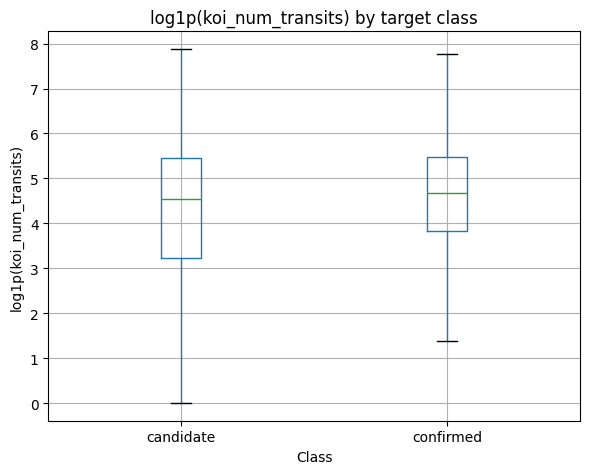

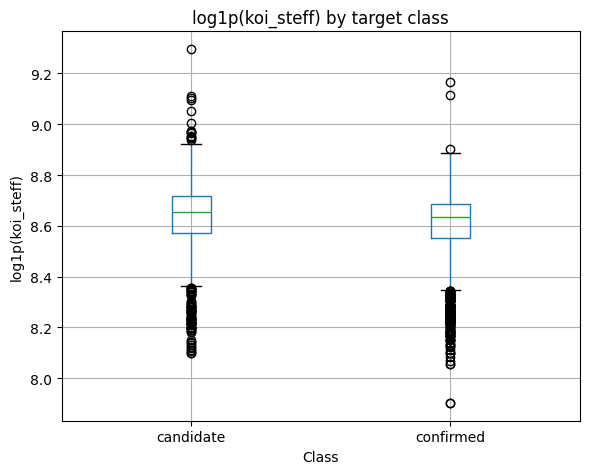

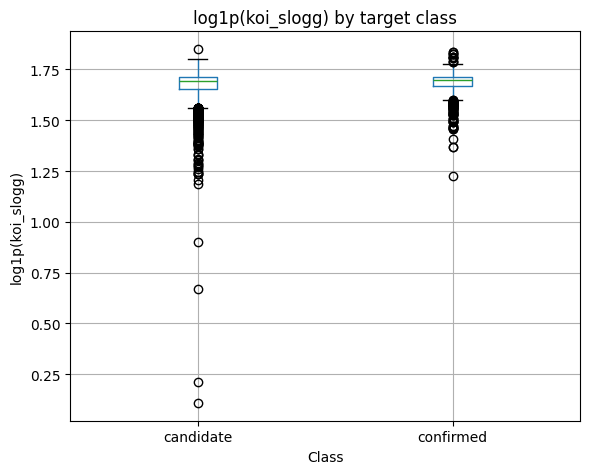

Skipping koi_smet: contains negative values.


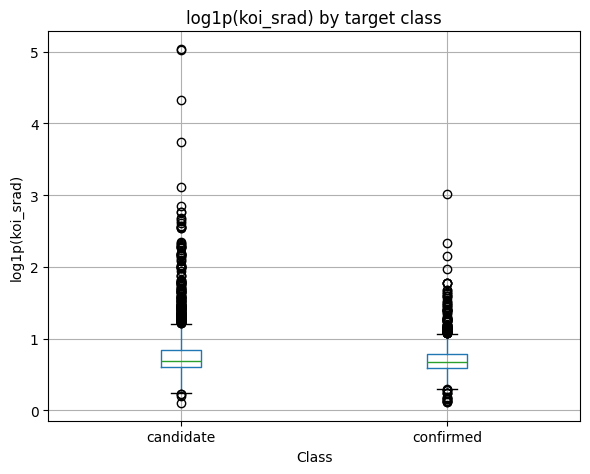

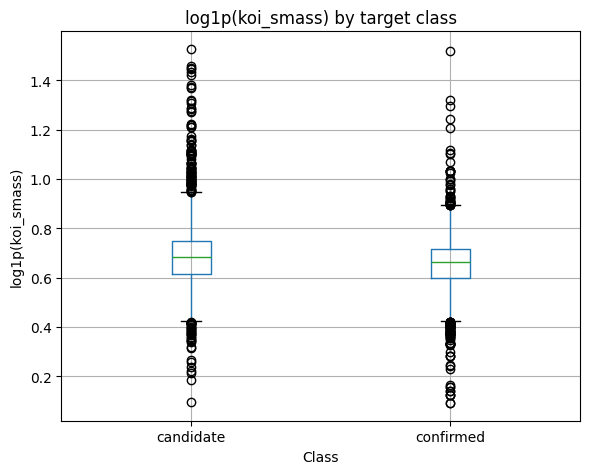

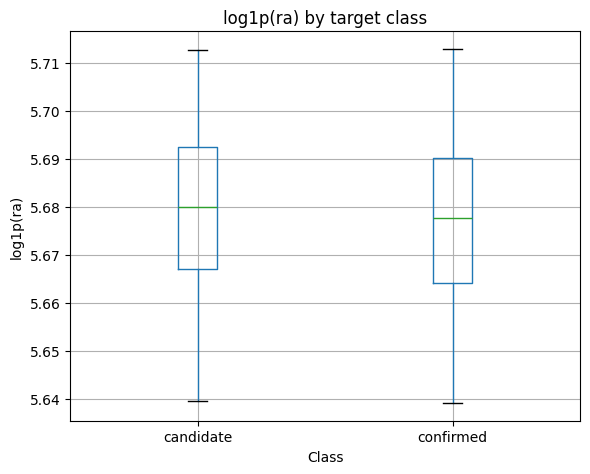

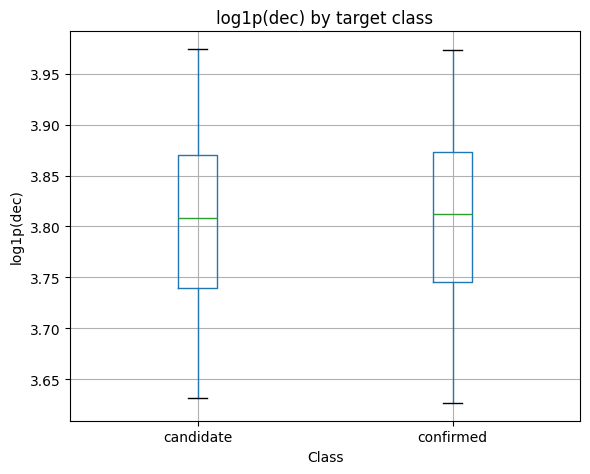

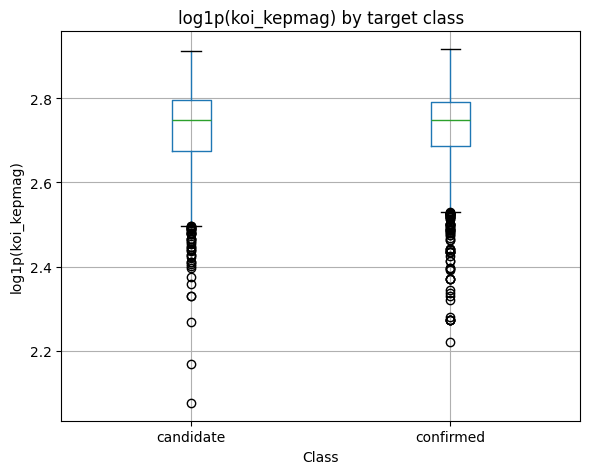

In [57]:
for feature in NUMERIC_COLUMNS:
    values = df[feature]

    if values.min(skipna=True) < 0:
        print(f"Skipping {feature}: contains negative values.")
        continue

    temp = df[["planet_label", feature]].copy()
    temp[f"log1p_{feature}"] = np.log1p(temp[feature])

    fig, ax = plt.subplots(figsize=(6, 5))

    temp.boxplot(
        column=f"log1p_{feature}",
        by="planet_label",
        ax=ax
    )

    ax.set_title(f"log1p({feature}) by target class")
    ax.set_xlabel("Class")
    ax.set_ylabel(f"log1p({feature})")

    plt.suptitle("")
    plt.tight_layout()
    plt.show()